# A Poisson Count Race as a Generative Bridge Between Logit and Probit

Choice

Vencislav Popov (Department of Psychology, University of Zurich)

This study unifies the two canonical discrete choice specifications - multinomial logit and multinomial probit - within a single count process. The model uses a Poisson count process race, wherein $K$ alternatives generate events according to independent Poisson processes. A choice is determined when an alternative reaches a cumulative count threshold $\theta$. At the single-event threshold, $\theta=1$, the model yields the Multinomial Logit (Luce choice rule). By normalizing the utility noise to maintain a constant variance, I show that as $\theta \to \infty$, the model converges to the Multinomial Probit. This formulation provides a parametric bridge in which $\theta$ governs the shape of the error distribution and a separate parameter, $\beta$, modulates the variance, while the systematic utilities $v_i$ are shared across all regimes. The generalized model uses a single stochastic accumulation mechanism: both regimes belong to the log-Gamma random utility family, with $\theta$ governing the transition between Gumbel and Gaussian noise shapes. The unification is distributional rather than dynamical: changes in $\theta$ do not represent a single decision-making system adjusting its threshold in real time, but rather compare different accumulation regimes at matched discriminability.

In [ ]:
source("R/race_functions.R")
source("R/model_illustrations.R")

library(ggplot2)
library(ggdist)
library(distributional)
library(patchwork)

# Introduction

Discrete choice models based on Random Utility (RU) theory \[@mcfaddenConditionalLogitAnalysis1974\] form a central pillar of mathematical psychology, econometrics, and cognitive science. In these models, each alternative in a choice set elicits a *latent* scalar quantity - often interpreted as strength, utility, or evidence - and the observed choices arise from a comparison of these latent quantities under stochastic variability. The general setup is surprisingly simple. Consider a decision-maker facing a set of $K \ge 2$ mutually exclusive alternatives. The utility associated with alternative $i$ can be decomposed into a systematic component, $v_i$, and a stochastic component, $\epsilon_i$:

$$
U_{i} = v_{i} + \epsilon_{i}, \quad i=1, \dots, K
$$

The decision-maker then selects the alternative with maximum utility:

$$
C = \arg \max_{i \in K} U_{i}
$$

While the term “utility” implies an economic setting, the underlying mathematical model concerns any situation in which choices are probabilistic. The core concept is that of a shared *random scale* on which multiple latent variables, each associated with a different choice, are represented. Any choice model that implements this assumption, together with the max choice rule, is said to have a random-scale representation or to be random-scale representible \[@falmagneRepresentationTheoremFinite1978a; @kellenTestingFoundationsSignal2021\].

Within this general framework, different assumptions about the distribution of errors, $\epsilon_i$, determine the structure of the choice model and its predictions. Two important classes dominate the field: logit-based models, derived from Luce’s choice axiom and extreme-value theory \[@luceIndividualChoiceBehavior1959; @yellottRelationshipLucesChoice1977; @mcfaddenConditionalLogitAnalysis1974\], and probit-based models, derived from Thurstone’s Theory of comparative judgements and gaussian Signal Detection Theory \[@robinsonHowPeopleBuild2023; @thurstoneLawComparativeJudgment1927; @hausmanConditionalProbitModel1978a; @wixtedForgottenHistorySignal2020\]. These two model families correspond to two types of error distributions:

1.  **Gumbel Errors:** If the $\epsilon_i$ terms are independent and identically distributed (i.i.d.) according to a Type I Extreme Value distribution, the choice probabilities follow the **Multinomial Logit (MNL)** or Softmax form.

2.  **Gaussian Errors:** If the $\epsilon_i$ terms follow a Multivariate Normal distribution (potentially allowing for correlated errors across alternatives) the choice probabilities are described by the **Multinomial Probit (MNP)** model.

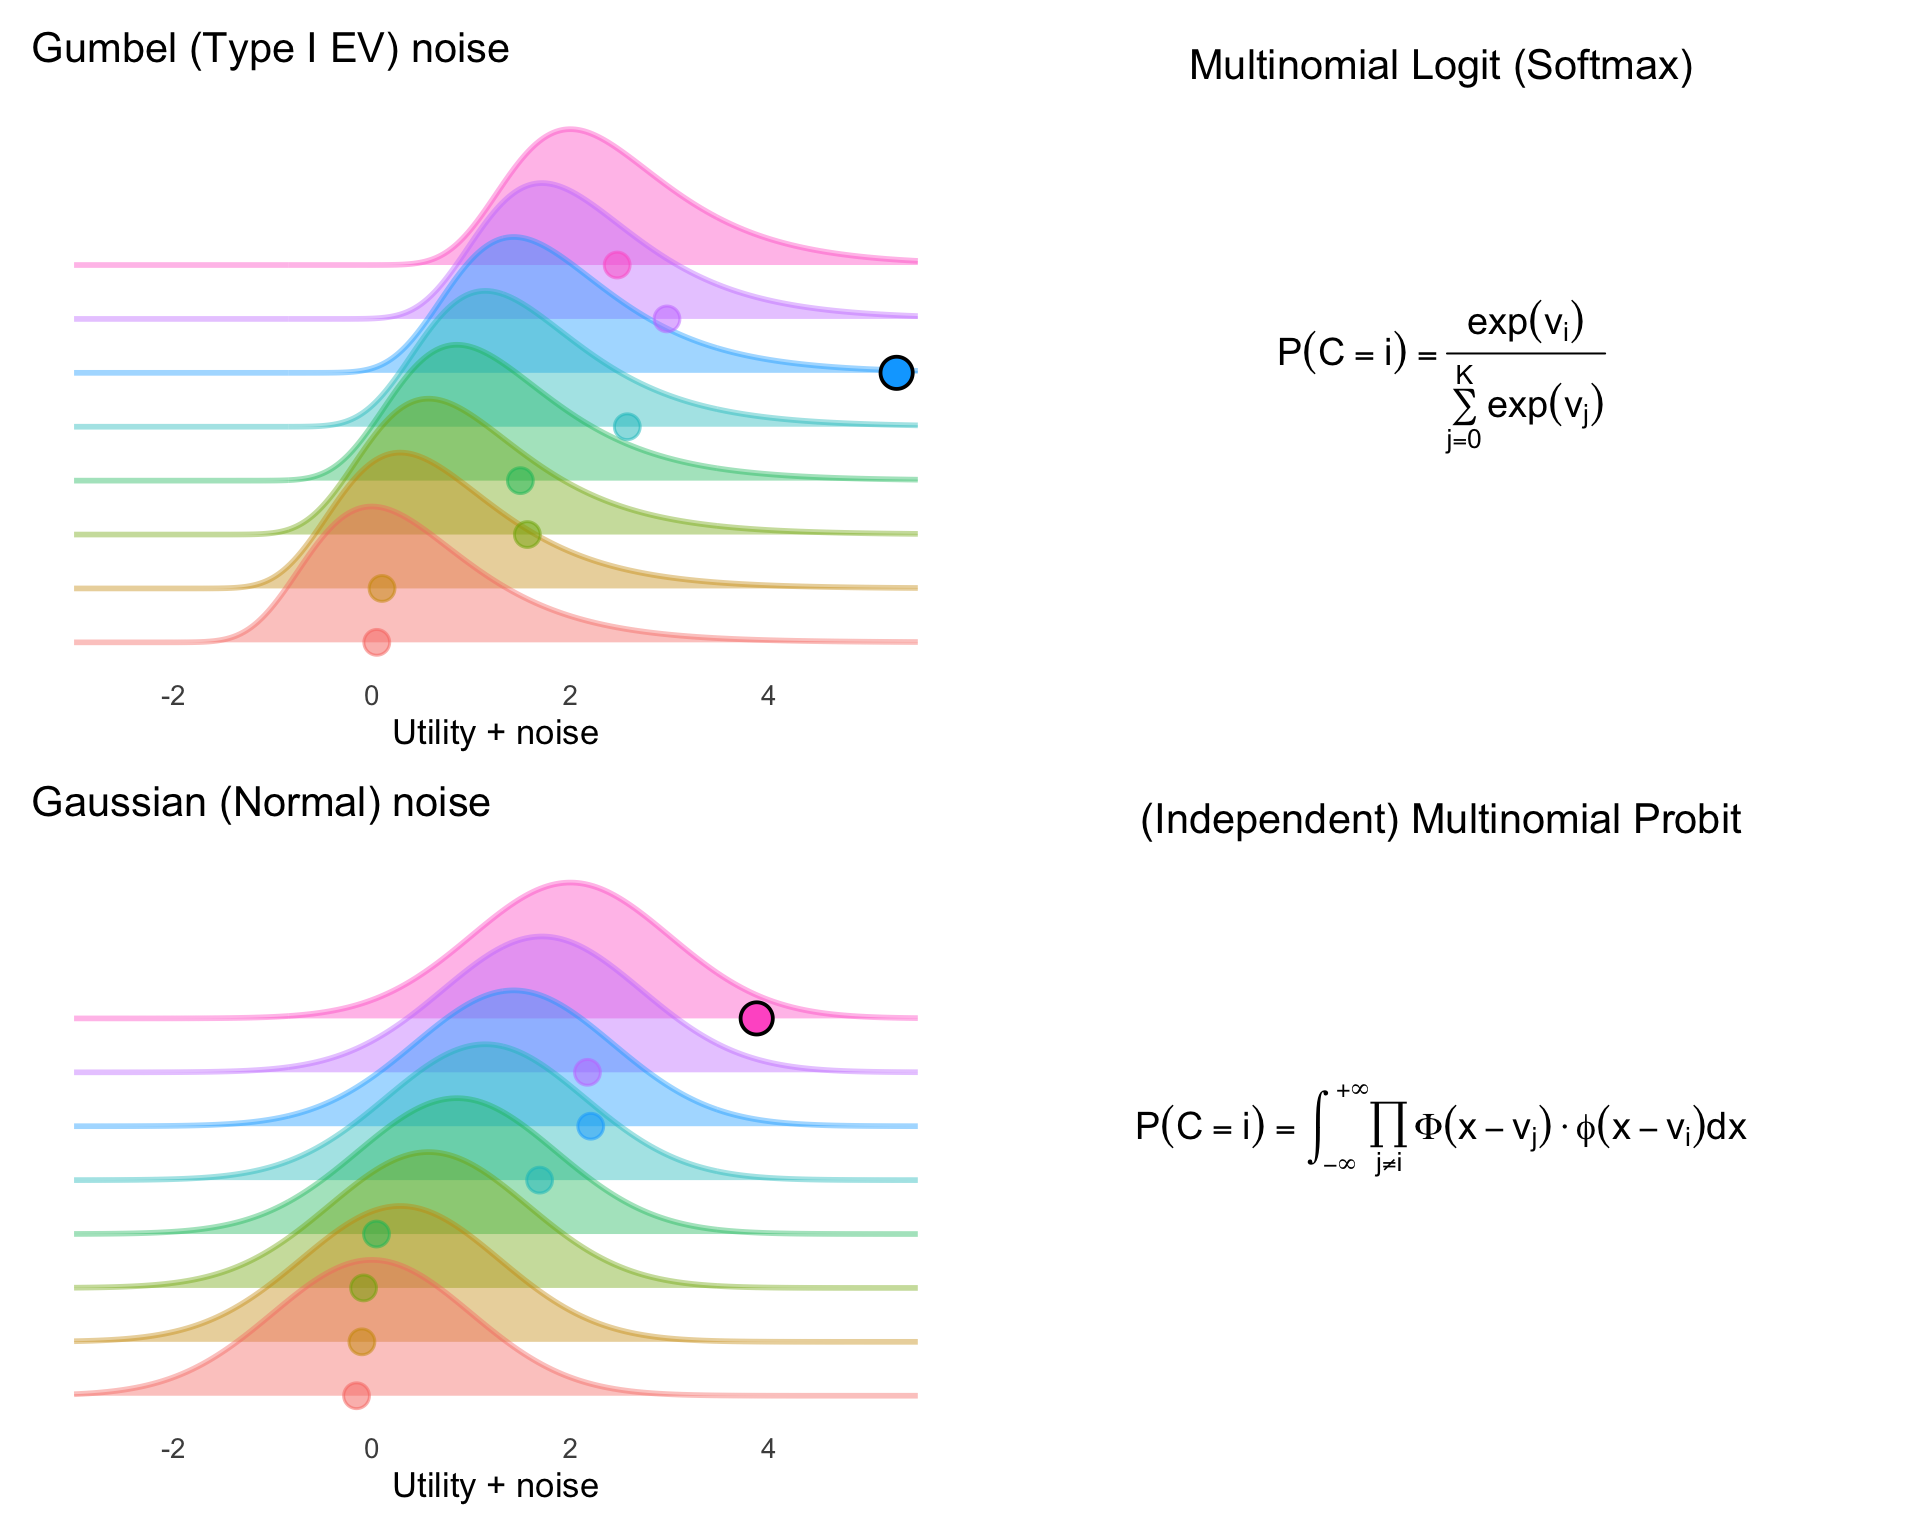

In [ ]:
utilities <- seq(0, 2, length.out = 8)
norm_util <- plot_utility_distributions(utilities,
  dist_fun = dist_normal,
  title = "Gaussian (Normal) noise",
  sd = 1
)
gumbel_util <- plot_utility_distributions(utilities,
  dist_fun = dist_gumbel,
  title = "Gumbel (Type I EV) noise",
  scale = sqrt(6) / pi
)

softmax_eq <- plot_softmax_equation()
probit_eq  <- plot_probit_equation()

(gumbel_util | softmax_eq) / (norm_util | probit_eq)

The random utility framework thus unifies axiomatic choice models \[@luceIndividualChoiceBehavior1959\] and measurement detection-based models \[@thurstoneLawComparativeJudgment1927\] under a single functional form. However, the unification currently stops there - the different error distributions reflect different assumptions about the generating process. As @robinsonHowPeopleBuild2023 recently put it, the two models “describe different ways of translating sensory evidence into decision variables.”.

The central question addressed in this paper is this: Can the two canonical random-utility discrete-choice specifications — multinomial logit and multinomial probit — be derived from a shared generative mechanism? Can we find a deeper unifying principle? The surprising answer is yes - both models can be derived as limit cases of a single stochastic evidence accumulation mechanism. The key distinction between the models is not the form of the utility noise itself, but the stopping rule governing how stochastic evidence is accumulated before a choice is made.

## Model overview

Take a **Poisson count race** \[@townsendStochasticModelingElementary1983; @smithTimedependentPoissonCounter2000a; @pikeResponseLatencyModels1973\], wherein each alternative generates stochastic events via an independent Poisson process. A decision is made when one alternative reaches a cumulative count threshold $\theta$. The threshold $\theta$ thus controls how much stochastic evidence must be accumulated before commitment.

Without any additional modifications, such a model predicts increasingly deterministic responses, and in the limit as $\theta \to \infty$ it leads to choosing the option with the highest utility 100% of the time. To prevent this, and to compare noise *shape* across $\theta$ independently of noise *scale*, we must standardize the stochastic utility component to unit variance for all $\theta$, with a separate parameter $\beta$ controlling the overall magnitude of stochasticity. With this normalization, we can establish three main results:

1.  At $\theta = 1$, this reduces exactly to the Multinomial Logit
2.  For any $\theta \ge 1$, the Poisson count race is isomorphic to a random utility model with log-Gamma noise, interpolating between Gumbel and Gaussian error distributions;
3.  As $\theta \to \infty$ the model converges to the Multinomial Probit.

From this perspective, logit and probit can be understood as members of a single parametric family of evidence accumulation models that differ in the accumulation stopping rule. Extreme-value noise and Gaussian noise arise as the two endpoint regimes of log-Gamma noise, which is the natural error distribution of Poisson count races. It is important to note, however, that this unification is algebraic and distributional rather than dynamical: the standartization that enables comparison across $\theta$ values compares different accumulation systems at matched discriminability, not a single system under threshold variation (see Section 5 for details).

While Poisson counter models have a rich history in mathematical psychology—particularly as accounts of response time distributions under time-varying evidence rates \[@townsendStochasticModelingElementary1983; @smithTimedependentPoissonCounter2000a; @pikeResponseLatencyModels1973\] - they have rarely been invoked to address the theoretical relationship between *static* discrete choice models. For example, Smith and Van Zandt (2000) showed that Poisson races yield choice probabilities governed by the incomplete Beta function when there are two options to choose from; but their analysis focused on relatively small integer thresholds $\theta \approx 5\text{–}10$ chosen to capture reaction-time skewness.

The present work takes a different perspective. Rather than treating the threshold as a fixed descriptive parameter, I examine the asymptotic behavior of the Poisson count race as $\theta \to \infty$ under variance-preserving identification. This shift in emphasis reveals that the Poisson race is not merely a model of latency, but a generative mechanism that continuously interpolates between the two canonical pillars of discrete choice: Multinomial Logit $\theta = 1$ and Multinomial Probit $\theta \to \infty$.

The remainder of the paper formalizes this framework, presents simulations illustrating the interpolation between regimes, and discusses implications for discrete choice modeling.

# The Generative Model: A Poisson Count Race

Let the accumulation of evidence or preference for each alternative $i$ be modeled by independent Poisson count processes, denoted $N_i(t)$, with rate parameters $\lambda_i > 0$. Here $N_i(t)$ represents cumulative count for alternative $i$ at time $t$.

Then, define a **count race** characterized by an integer threshold $\theta \ge 1$. The process terminates as soon as any single alternative accumulates $\theta$ events.

**Definition 1 (Stopping Time).** The stopping time for the system is the first time any process hits the threshold:

$$
\tau_{\theta} = \inf \{t \ge 0 : \max_{i} N_i(t) = \theta \}
$$

**Definition 2 (Choice).** The chosen alternative is the specific process that triggers the stopping time:

$$
C = \arg \max_{i} N_i(\tau_{\theta})
$$

## Transformation to Waiting Times

To map this stochastic process to a random utility framework, consider $T_i^{(\theta)}$, the waiting time until the $i$-th process records its $\theta$-th event:

$$
T_i^{(\theta)} := \inf \{t : N_i(t) = \theta \}
$$

For a Poisson process with rate $\lambda_i$, the waiting time to the $\theta$-th jump follows a Gamma (Erlang) distribution with shape $\theta$ and rate $\lambda_i$:

$$
T_i^{(\theta)} \sim \text{Gamma}(\text{shape}=\theta, \text{rate}=\lambda_i)
$$

The condition that alternative $i$ wins the race is equivalent to observing the minimum waiting time:

$$
C = \arg \min_{i} T_i^{(\theta)}
$$

## The Random Utility Representation

Since the Poisson processes are independent, the waiting times $T_1^{(\theta)}, \ldots, T_K^{(\theta)}$ are mutually independent. Utilizing the scaling property of the Gamma distribution, we can express each waiting time as:

$$
T_i^{(\theta)} \stackrel{d}{=} \frac{G_i}{\lambda_i}
$$

where $G_1, \ldots, G_K \stackrel{\text{i.i.d.}}{\sim} \text{Gamma}(\theta, 1)$ are standard Gamma random variables. The choice problem then becomes:

$$
C = \arg \min_{i} \left( \frac{G_i}{\lambda_i} \right)
$$

Applying the natural logarithm and taking the negative, a monotonic transformation, reverses the optimization direction from minimization to maximization:

$$
\begin{aligned} C &= \arg \min_{i} (\log G_i - \log \lambda_i) \\ &= \arg \max_{i} (\log \lambda_i - \log G_i) \end{aligned}
$$

This establishes an exact Random Utility Model (RUM) structure:

$$
U_i^{(\theta)} = v_i + \epsilon_i^{(\theta)}
$$

where:

-   **Systematic Utility:** $v_i = \log \lambda_i$  
-   **Stochastic Error:** $\epsilon_i^{(\theta)} = -\log G_i$, with $G_i \sim \text{Gamma}(\theta, 1)$.

Thus, the Poisson count race is isomorphic to a Random Utility Model characterized by Log-Gamma noise.

> **Result 1 (Log-Gamma Random Utility Family)**
>
> For any integer threshold $\theta \ge 1$, the Poisson count race induces a random utility model $U_i^{(\theta)} = \log \lambda_i - \log G_i$ with i.i.d. log-Gamma($\theta$) noise.

# The Logit Boundary ($\theta = 1$)

In the specific instance where the threshold is a single event ($\theta = 1$), the waiting time distribution simplifies to the Exponential distribution:

$$
G_i \sim \text{Gamma}(1, 1) \equiv \text{Exponential}(1)
$$

A fundamental property of Extreme Value Theory is the relationship between the Exponential and Gumbel distributions:

$$
X \sim \text{Exp}(1) \implies -\log(X) \sim \text{Gumbel}(\text{Type I EV})
$$

Therefore, when $\theta=1$, the noise terms $\epsilon_i^{(1)}$ are i.i.d. standard Gumbel. This recovers the exact Multinomial Logit formula:

$$
\Pr(C=i) = \frac{\exp(v_i)}{\sum_{j=1}^K \exp(v_j)} = \frac{\lambda_i}{\sum_{j=1}^K \lambda_j}
$$

> **Result 2 (Logit Boundary)**
>
> The Poisson count race with threshold $\theta=1$ recovers the Multinomial Logit model exactly, with deterministic utility components equal to the log rate of their poisson counterparts. The accumulation of a single unit of evidence corresponds to the Luce Choice Rule (Softmax). This is a classic, well-known derivation.

# Variance normalization

For thresholds $\theta > 1$, the error distribution deviates from the Gumbel form. More critically, as $\theta$ increases, the variance of the error term diminishes. Specifically, for $\epsilon^{(\theta)} = -\log G$ where $G \sim \text{Gamma}(\theta, 1)$, the moments are:

$$
\begin{aligned} \mathbb{E}[\epsilon^{(\theta)}] &= -\psi(\theta) \\ \text{Var}(\epsilon^{(\theta)}) &= \psi_1(\theta) \end{aligned}
$$

where $\psi(\cdot)$ is the digamma function and $\psi_1(\cdot)$ is the trigamma function.

As $\theta \to \infty$, the variance $\psi_1(\theta) \approx 1/\theta \to 0$. Without intervention, the model would converge to a deterministic choice rule (argmax of systematic utilities) simply because the noise vanishes. To facilitate a meaningful comparison of error shapes across varying $\theta$, we must enforce a consistent scale.

Define the standardized noise term $Z_i^{(\theta)}$ to have zero mean and unit variance for all $\theta$:

$$
Z_i^{(\theta)} := \frac{\epsilon_i^{(\theta)} - \mu_\theta}{\sigma_\theta} = \frac{-\log G_i + \psi(\theta)}{\sqrt{\psi_1(\theta)}}
$$

This leads to family of utility models with matched discriminability:

$$
U_i^{(\theta)} = v_i + \beta Z_i^{(\theta)}
$$

Here:

-   $v_i$ is the systematic utility (evidence rate).
-   $\theta$ governs the shape of the noise (from skewed Gumbel to symmetric Gaussian).
-   $\beta$ governs the temperature (the magnitude of noise relative to utility).

An important caveat accompanies this construction. In a random utility model, rescaling all utilities by a common positive constant does not change choice probabilities. If we multiply both terms by $\sigma_\theta = \sqrt{\psi_1(\theta)}$, we would not change the predicted probabilities. Therefore, the variance-normalized model $U_i^{(\theta)} = v_i + \beta Z_i^{(\theta)}$ is observationally equivalent to a model with systematic utilities $v_i \sigma_\theta$ and *unstandardized* log-Gamma noise $\epsilon_i^{(\theta)}$.

This has an important theoretical consequence: the standardized distributions cannot describe the behavior of a single accumulation system under threshold variation. For a fixed set of Poisson rates $\lambda_i$, increasing $\theta$ both reshapes the noise and reduces its variance; the variance reduction alone drives choice toward determinism regardless of shape. The standardization removes this confound by comparing across systems with different effective rate structures — specifically, the effective rates would need to scale as $\lambda_i^{1/\sigma_\theta}$ to maintain constant discriminability. However, it is not psychologically plausible that a decision-maker can affect the utilities / poisson rates in exactly the right way if they choose a higher, more conservative threshold. Simply put - a single decision-making system cannot wait its way from a logit to a probit model while keeping discriminability fixed.

The unification established here is therefore *distributional* — logit and probit belong to the same parametric family of log-Gamma random utility models — rather than *dynamical*. One cannot convert a logit-like decision process into a probit-like one merely by raising the decision threshold within a single system. Rather, different regimes likely describe the functioning of different decision-making systems.

# The Probit Limit ($\theta \to \infty$)

This section establishes the asymptotic behavior of the temperature-identified model.

Recall that $G_i \sim \text{Gamma}(\theta, 1)$. For integer $\theta$, $G_i$ can be represented as the sum of $\theta$ independent exponential variables: $G_i = \sum_{j=1}^{\theta} E_{ij}$. By the Central Limit Theorem, the standardized variable converges to a standard normal distribution:

$$
\frac{G_i - \theta}{\sqrt{\theta}} \xrightarrow{d} \mathcal{N}(0, 1)
$$

We are interested in the distribution of the log-transformed variable, $\epsilon_i^{(\theta)} = -\log G_i$. By applying the Delta Method with the transformation $g(x) = -\log x$, the asymptotic distribution of $-\log G_i$ is normal with variance $[g'(\theta)]^2 \cdot \text{Var}(G_i) = (-1/\theta)^2 \cdot \theta = 1/\theta$.

Standardizing this result matches our temperature identification scaling. Since $\psi_1(\theta) \sim 1/\theta$ for large $\theta$, the standardized term converges to the standard normal:

$$
Z_i^{(\theta)} \xrightarrow{d} \mathcal{N}(0, 1)
$$

Consequently, the vector of random utilities converges in distribution:

$$
(v_i + \beta Z_i^{(\theta)})_{i=1}^K \xrightarrow{d} (v_i + \beta Z_i)_{i=1}^K
$$

where $Z_i \stackrel{i.i.d.}{\sim} \mathcal{N}(0, 1)$.

> **Result 3 (Probit Limit)**
>
> As $\theta \to \infty$, the Temperature-Identified Poisson race converges to the Independent Multinomial Probit model. Within the temperature-identified family, Logit corresponds to the $\theta=1$ member and Probit to the $\theta \to \infty$ limit. This characterizes the two models as occupying different positions within a single parametric family of log-Gamma random utility models, indexed by the accumulation threshold.

# Simulation Studies: Binary Choice

To illustrate how the Poisson count race family interpolates between Logit and Probit, I conducted a simulation study in the binary choice setting ($K=2$). This setting admits closed-form choice probabilities and allows direct visual comparison with both classical models.

Let $\lambda_1$ and $\lambda_2$ denote the Poisson rates of the two alternatives, and define the log-rate ratio $x = \log(\lambda_1/\lambda_2)$. The probability that alternative 1 wins the race can be expressed in closed form using the regularized incomplete Beta function:

$$
\Pr(C = 1 \mid x, \theta) = I_{\sigma(x)}(\theta, \theta)
$$

where $I_p(a, b)$ is the regularized incomplete Beta function and $\sigma(x) = (1 + e^{-x})^{-1}$. To see this, note that alternative 1 wins the race if and only if $T_1^{(\theta)} < T_2^{(\theta)}$, where $T_i^{(\theta)} \sim \text{Gamma}(\theta, \lambda_i)$. Equivalently, defining $W = T_1^{(\theta)} / (T_1^{(\theta)} + T_2^{(\theta)})$, we have $W \sim \text{Beta}(\theta, \theta)$ when evaluated at $p = \lambda_1 / (\lambda_1 + \lambda_2) = \sigma(x)$, giving $\Pr(T_1 < T_2) = I_{\sigma(x)}(\theta, \theta)$. For $\theta = 1$, this reduces exactly to $\sigma(x)$, the logistic function.

When choice probabilities are plotted directly as a function of $x$ for increasing $\theta$, the choice function becomes increasingly steep and converges to a step function at $x = 0$, reflecting deterministic selection of the alternative with the larger rate. This confirms that without temperature identification, increasing the count threshold simply reduces stochasticity rather than inducing Gaussian behavior.

To compare noise *shape* independently of noise *scale*, I adopted the temperature identification introduced in Section 5. For binary choice, the variance of the utility noise difference is $\text{Var}(\epsilon_1^{(\theta)} - \epsilon_2^{(\theta)}) = 2\psi_1(\theta)$. I therefore define the standardized signal $s = x / \sqrt{2\psi_1(\theta)}$. On this variance-matched axis, the Logit reference ($\theta = 1$) uses $\text{sd}_{\text{diff}} = \pi/\sqrt{3}$ (the standard deviation of the difference of two independent Gumbel variates), and the Probit reference is simply $\Phi(s)$.

For the multinomial simulations, the same principle applies. The logit reference uses an effective inverse temperature of $\pi / (\beta\sqrt{6})$, which ensures the Gumbel noise has standard deviation matching $\beta$ under the unit-variance convention. The probit reference uses noise scale $\beta$ directly. All simulations use $\beta = 1$ unless otherwise noted. Under this normalization, the $\theta = 1$ Poisson race coincides exactly with the variance-matched logit curve, while increasing $\theta$ yields choice functions that converge uniformly to the probit curve.

Because logit and probit are themselves numerically close under variance matching, the differences between models are small in absolute magnitude but systematic. To make these differences visible, @fig-residuals plots residuals relative to the variance-matched Logit model. At $\theta = 1$, the residual is identically zero (exact Logit). As $\theta$ increases, the residuals grow smoothly and converge toward the Probit$-$Logit difference curve, with the maximum absolute deviation from probit decaying rapidly in $\theta$. This confirms that the temperature-identified Poisson count race defines a continuous, parameterized family of choice rules that interpolates smoothly between logit-like and probit-like behavior.

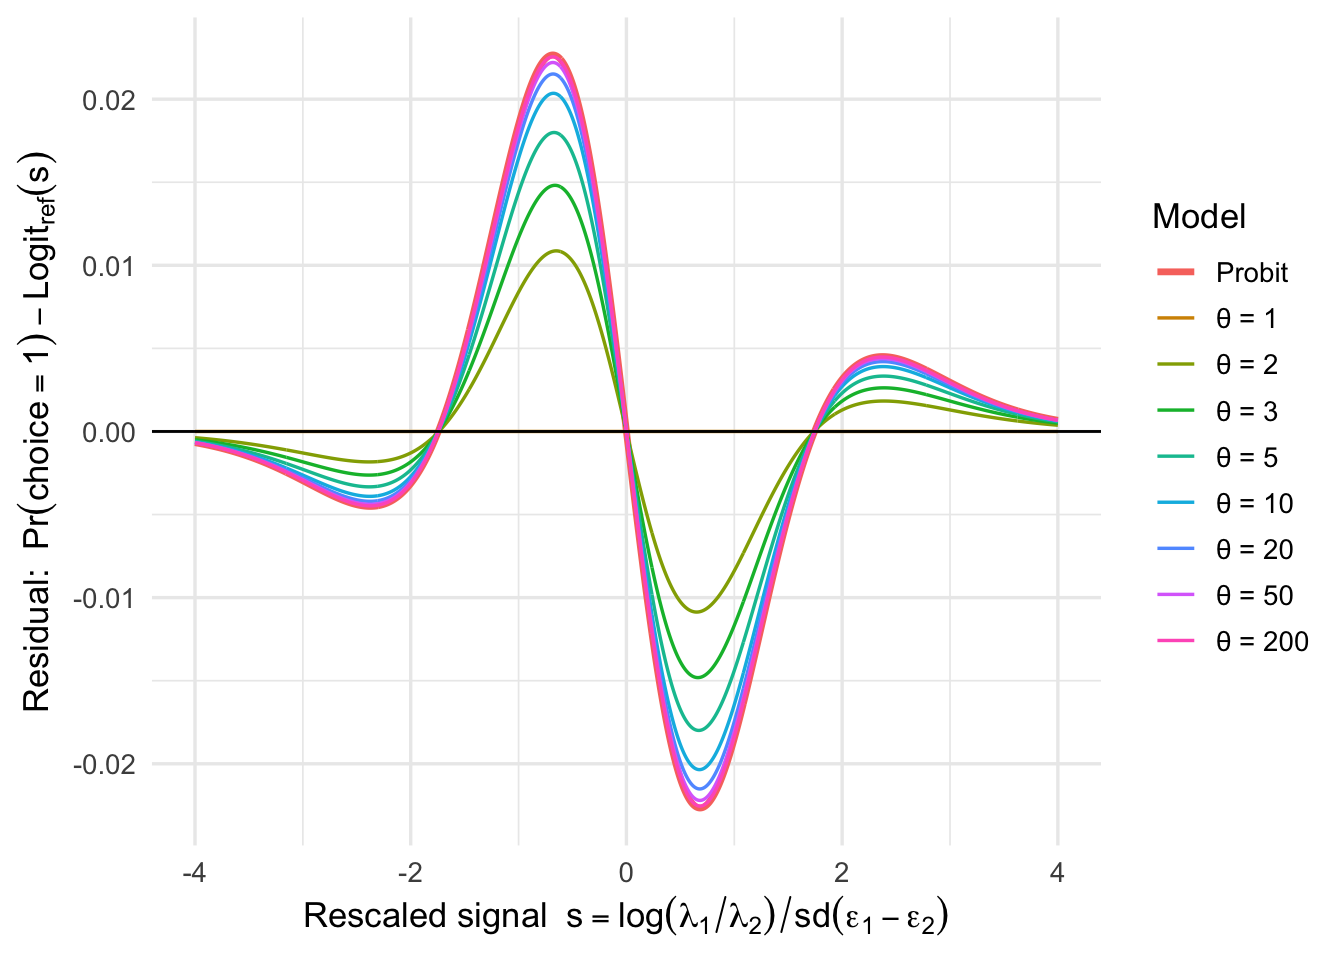

In [ ]:
s <- seq(-4, 4, length.out = 1200)
thetas <- c(1, 2, 3, 5, 10, 20, 50, 200)

# Build data frame
df <- data.frame(
  s = s,
  residual = probit_residual(s),
  model = "Probit"
)

for (th in thetas) {
  df <- rbind(df, data.frame(
    s = s,
    residual = race_residual(s, th),
    model = paste0("θ = ", th)
  ))
}

# Order factor levels so Probit appears first, then thetas in order
df$model <- factor(df$model,
  levels = c("Probit", paste0("θ = ", thetas))
)

ggplot(df, aes(x = s, y = residual, color = model, linewidth = model)) +
  geom_line() +
  geom_hline(yintercept = 0, linewidth = 0.5) +
  scale_linewidth_manual(
    values = c("Probit" = 1.2, setNames(rep(0.6, length(thetas)),
                                         paste0("θ = ", thetas)))
  ) +
  labs(
    x = expression("Rescaled signal " ~ s == log(lambda[1]/lambda[2]) / sd(epsilon[1] - epsilon[2])),
    y = expression("Residual: " ~ Pr(choice == 1) - Logit[ref](s)),
    color = "Model",
    linewidth = "Model"
  ) +
  theme_minimal(base_size = 13) +
  theme(legend.position = "right")

# Simulation Studies: Multinomial K-alternative Choice

The binary simulation demonstrates that the temperature-identified Poisson count race interpolates smoothly between Logit ($\theta = 1$) and Probit ($\theta \to \infty$) in the two-alternative case. Here I extend this analysis to the multinomial setting ($K > 2$), where the differences between logit and probit become richer and more consequential.

In the binary case, logit and probit choice functions differ only in the shape of the psychometric curve—a subtle quantitative distinction. With three or more alternatives, additional qualitative differences emerge. Most prominently, the Multinomial Logit model satisfies the *Independence of Irrelevant Alternatives* (IIA) property: the ratio of choice probabilities for any two alternatives is independent of the remaining alternatives in the choice set \[@luceIndividualChoiceBehavior1959\]. The Multinomial Probit model, even with independent errors, does not share this property \[@hausmanConditionalProbitModel1978a\]. The Poisson count race therefore provides a window into how IIA-like behavior gradually weakens as the noise distribution transitions from Gumbel to Gaussian.

The multinomial simulations are organised around five questions:

1.  **Convergence**: How quickly do Poisson count race choice probabilities converge to the Probit reference as $\theta$ increases, and does the rate of convergence depend on $K$?
2.  **Probability vectors**: How does the full distribution over alternatives change as $\theta$ varies from 1 to large values?
3.  **Set-size scaling**: How does the probability of choosing a target alternative scale with the number of competitors, and how does this scaling differ between logit, probit, and intermediate regimes?
4.  **Independence of Irrelevant Alternatives**: How does the IIA property—exact under logit—erode as $\theta$ increases toward the probit regime?
5.  **Parameter invariance**: When misspecified logit or probit models are fit to Poisson count race data, which model yields parameters that are invariant to $K$?

All simulations use Monte Carlo sampling with $10^6$ to $10^7$ replications per condition unless otherwise noted.

## Study 1: Convergence to Probit

I first examine how the total variation (TV) distance between the Poisson count race choice probabilities and the Logit / Probit references changes as a function of $\theta$, for different numbers of alternatives $K$.

For each $K$, I use linearly spaced utilities $v_i = (K - i)/(K - 1)$ for $i = 1, \ldots, K$, ensuring that the best and worst alternatives always have utilities 1 and 0 regardless of $K$. The temperature is fixed at $\beta = 1$.

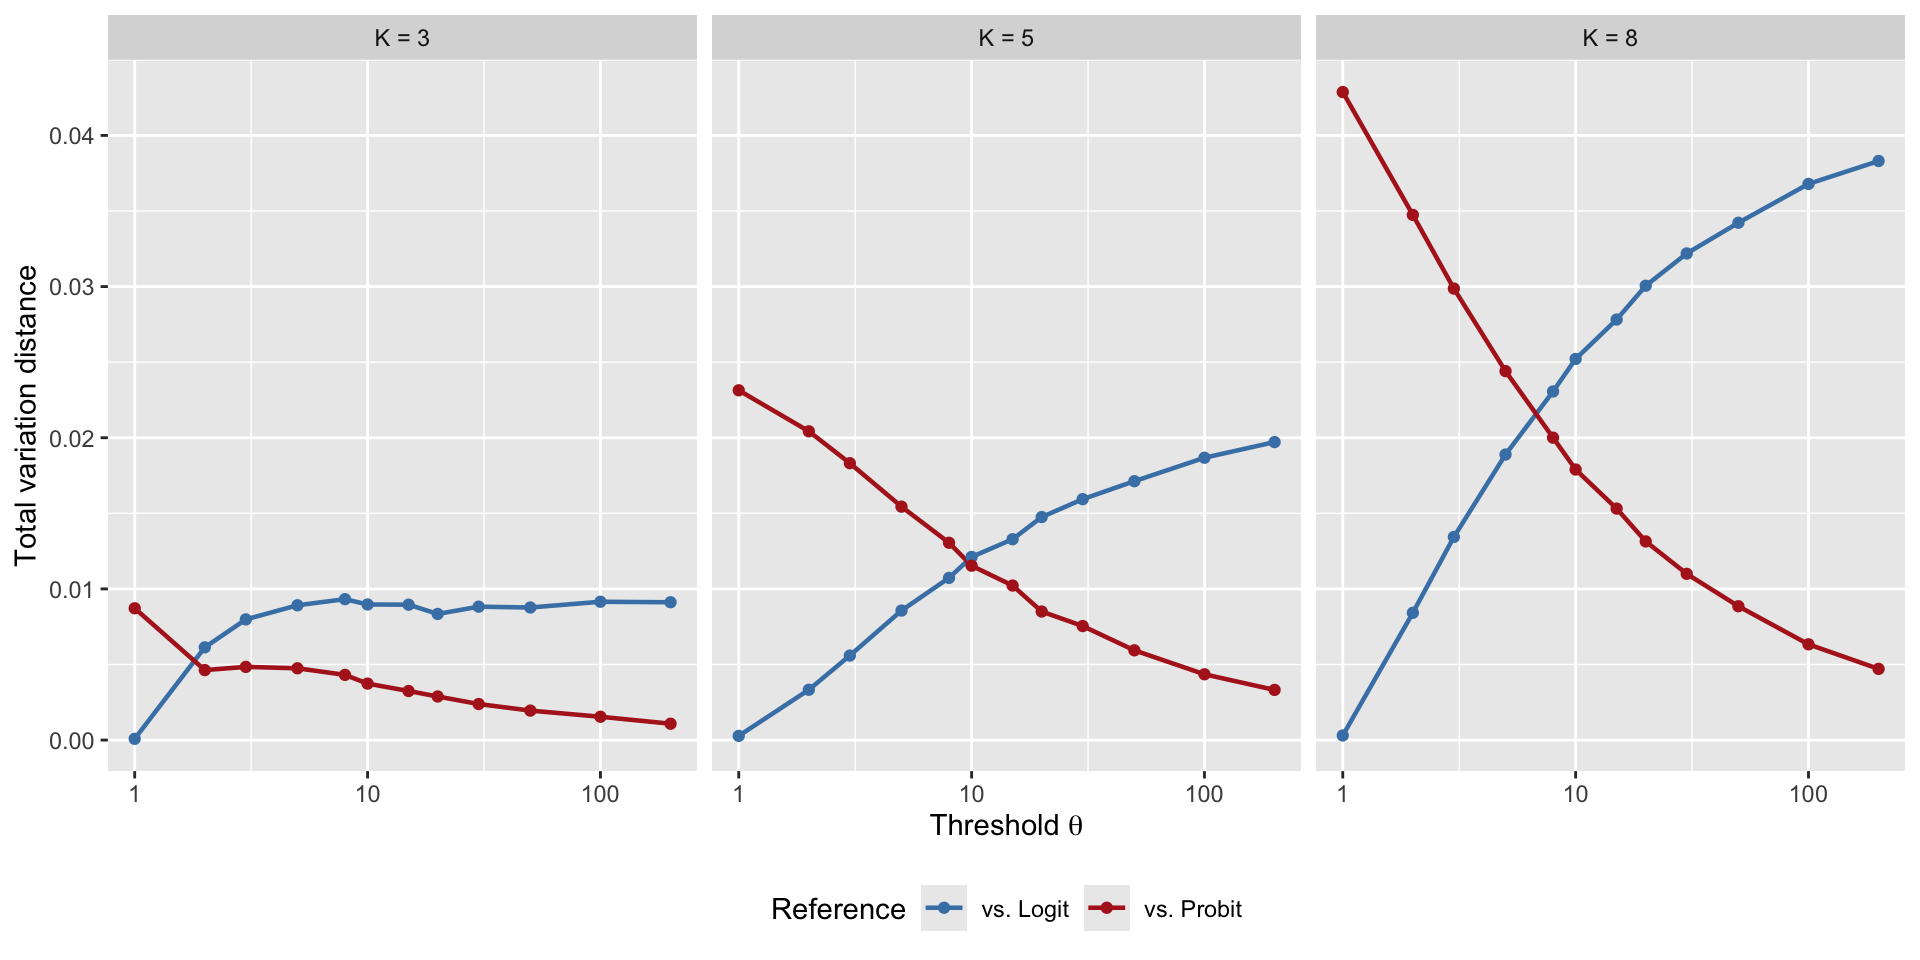

In [ ]:
set.seed(42)
n_sim <- 1e7

Ks <- c(3, 5, 8)
thetas <- c(1, 2, 3, 5, 8, 10, 15, 20, 30, 50, 100, 200)

results <- data.frame()

for (K in Ks) {
  v <- seq(1, 0, length.out = K)  # linearly spaced utilities
  
  # Reference models
  p_logit <- mnl_probs(v, beta = 1)
  p_probit <- mnp_probs(v, beta = 1, n_sim = 2e6)
  
  for (th in thetas) {
    p_race <- race_choice_probs(v, theta = th, beta = 1, n_sim = n_sim)
    
    results <- rbind(results, data.frame(
      K = K,
      theta = th,
      tv_logit = tv_dist(p_race, p_logit),
      tv_probit = tv_dist(p_race, p_probit)
    ))
  }
}

# Reshape for plotting
df_tv <- rbind(
  data.frame(K = results$K, theta = results$theta, 
             TV = results$tv_logit, Reference = "vs. Logit"),
  data.frame(K = results$K, theta = results$theta, 
             TV = results$tv_probit, Reference = "vs. Probit")
)
df_tv$K_label <- paste0("K = ", df_tv$K)
df_tv$K_label <- factor(df_tv$K_label, levels = paste0("K = ", Ks))

ggplot(df_tv, aes(x = theta, y = TV, color = Reference)) +
  geom_line(linewidth = 0.8) +
  geom_point(size = 1.5) +
  scale_x_log10() +
  facet_wrap(~K_label) +
  scale_color_manual(values = c("vs. Logit" = "steelblue", "vs. Probit" = "firebrick")) +
  labs(
    x = expression("Threshold " * theta),
    y = "Total variation distance",
    color = "Reference"
  ) +
  theme(legend.position = "bottom")

## Study 2: Choice Probability Vectors

To visualise how the full distribution over alternatives evolves with $\theta$, I fix $K = 5$ with utilities $v = (2.0,\; 1.5,\; 1.0,\; 0.5,\; 0.0)$ and plot the choice probability for each alternative across a range of thresholds.

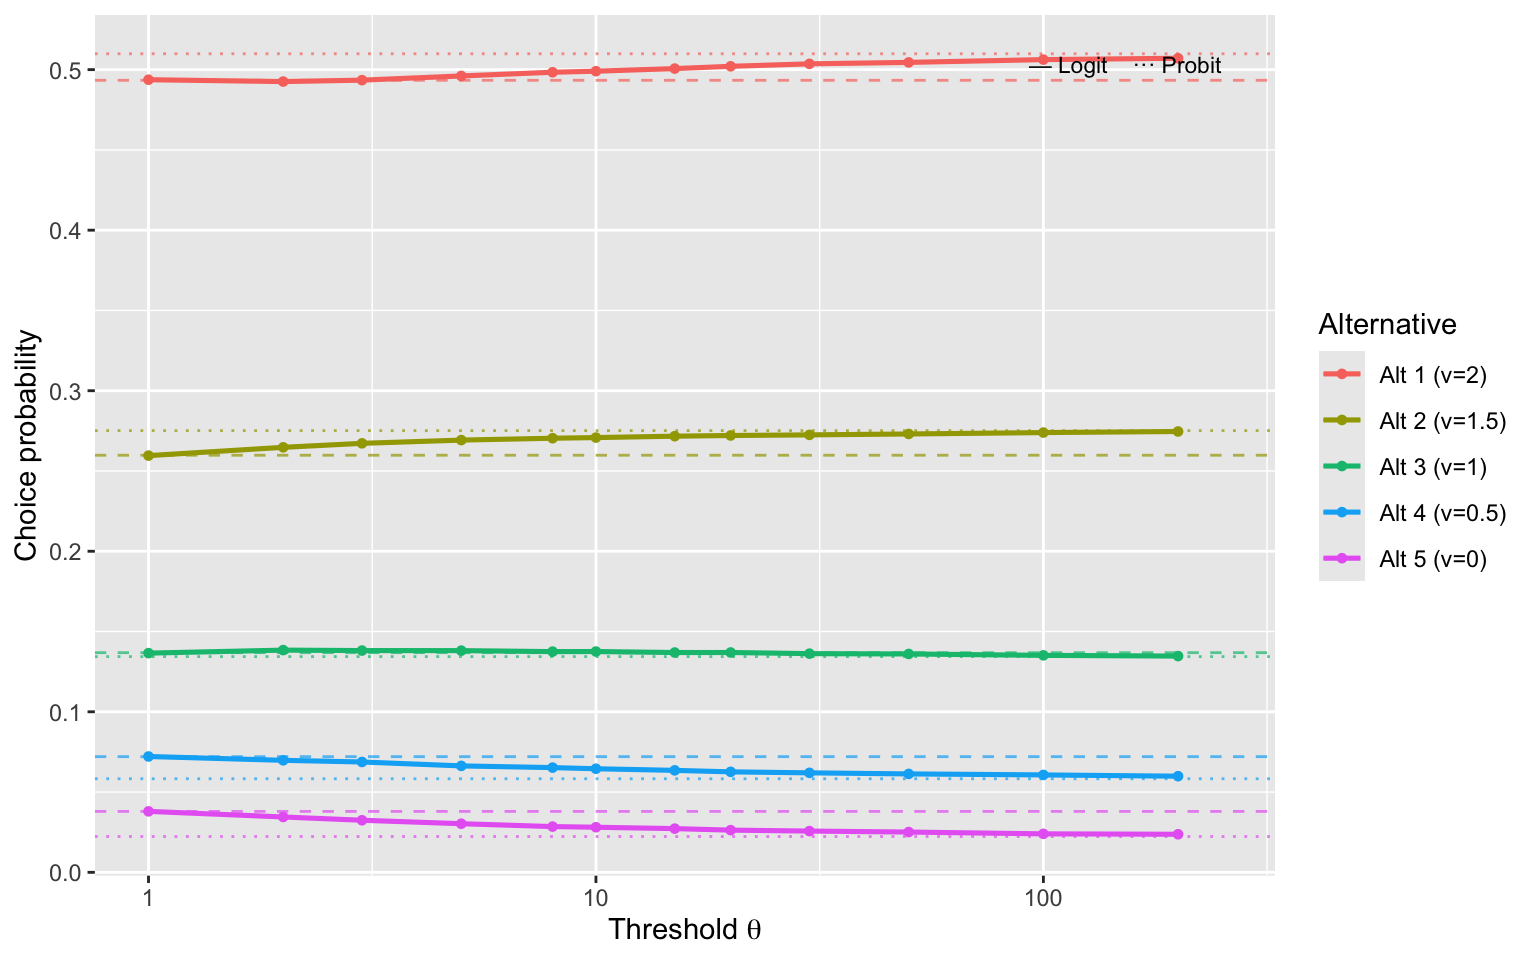

In [ ]:
set.seed(123)
K <- 5
v <- seq(2, 0, length.out = K)
thetas_fine <- c(1, 2, 3, 5, 8, 10, 15, 20, 30, 50, 100, 200)
n_sim <- 2e6

# References
p_logit <- mnl_probs(v, beta = 1)
p_probit <- mnp_probs(v, beta = 1, n_sim = 5e6)

# Race probabilities across theta
df_probs <- data.frame()
for (th in thetas_fine) {
  p <- race_choice_probs(v, theta = th, beta = 1, n_sim = n_sim)
  for (i in 1:K) {
    df_probs <- rbind(df_probs, data.frame(
      theta = th,
      alternative = paste0("Alt ", i, " (v=", v[i], ")"),
      prob = p[i]
    ))
  }
}

# Reference data
df_ref <- data.frame()
for (i in 1:K) {
  df_ref <- rbind(df_ref, data.frame(
    alternative = paste0("Alt ", i, " (v=", v[i], ")"),
    logit = p_logit[i],
    probit = p_probit[i]
  ))
}

df_probs$alternative <- factor(df_probs$alternative, 
                                levels = paste0("Alt ", 1:K, " (v=", v, ")"))
df_ref$alternative <- factor(df_ref$alternative,
                              levels = paste0("Alt ", 1:K, " (v=", v, ")"))

ggplot(df_probs, aes(x = theta, y = prob, color = alternative)) +
  geom_line(linewidth = 0.9) +
  geom_point(size = 1.2) +
  geom_hline(data = df_ref, aes(yintercept = logit, color = alternative), 
             linetype = "dashed", linewidth = 0.5, alpha = 0.7) +
  geom_hline(data = df_ref, aes(yintercept = probit, color = alternative), 
             linetype = "dotted", linewidth = 0.5, alpha = 0.7) +
  scale_x_log10() +
  labs(
    x = expression("Threshold " * theta),
    y = "Choice probability",
    color = "Alternative"
  ) +
  theme(legend.position = "right") +
  annotate("text", x = 250, y = max(p_logit) + 0.01, label = "— Logit    ··· Probit", 
           size = 3, hjust = 1)

## Study 3: Set-Size Scaling

A critical diagnostic for discriminating between logit and probit models is the effect of adding alternatives to the choice set \[@robinsonHowPeopleBuild2023\]. Under MNL, the probability of choosing a target alternative with fixed utility is strictly determined by the ratio of its strength to the total strength. Under MNP, the scaling with set size differs because the probability of “winning” the maximum comparison depends on the shape of the noise distribution.

I fix a target alternative with utility $v_\text{target} = 1$ and add $K - 1$ equal competitors, each with utility $v_\text{comp} = 0$. As $K$ grows, I track the probability of choosing the target.

Under MNL, the choice probability is $P(\text{target}) = e^a / (e^a + K - 1)$, where $a = v_t \cdot \pi / (\beta \sqrt{6})$ is the effective scaled utility.

Under MNP: $P(\text{target}) = \int \phi(z) \,\Phi(v_t/\beta + z)^{K-1}\, dz$ (by symmetry of the $K - 1$ equal competitors). This integral reveals that probit’s thinner tails give the target a larger advantage over many competitors than logit’s heavier tails.

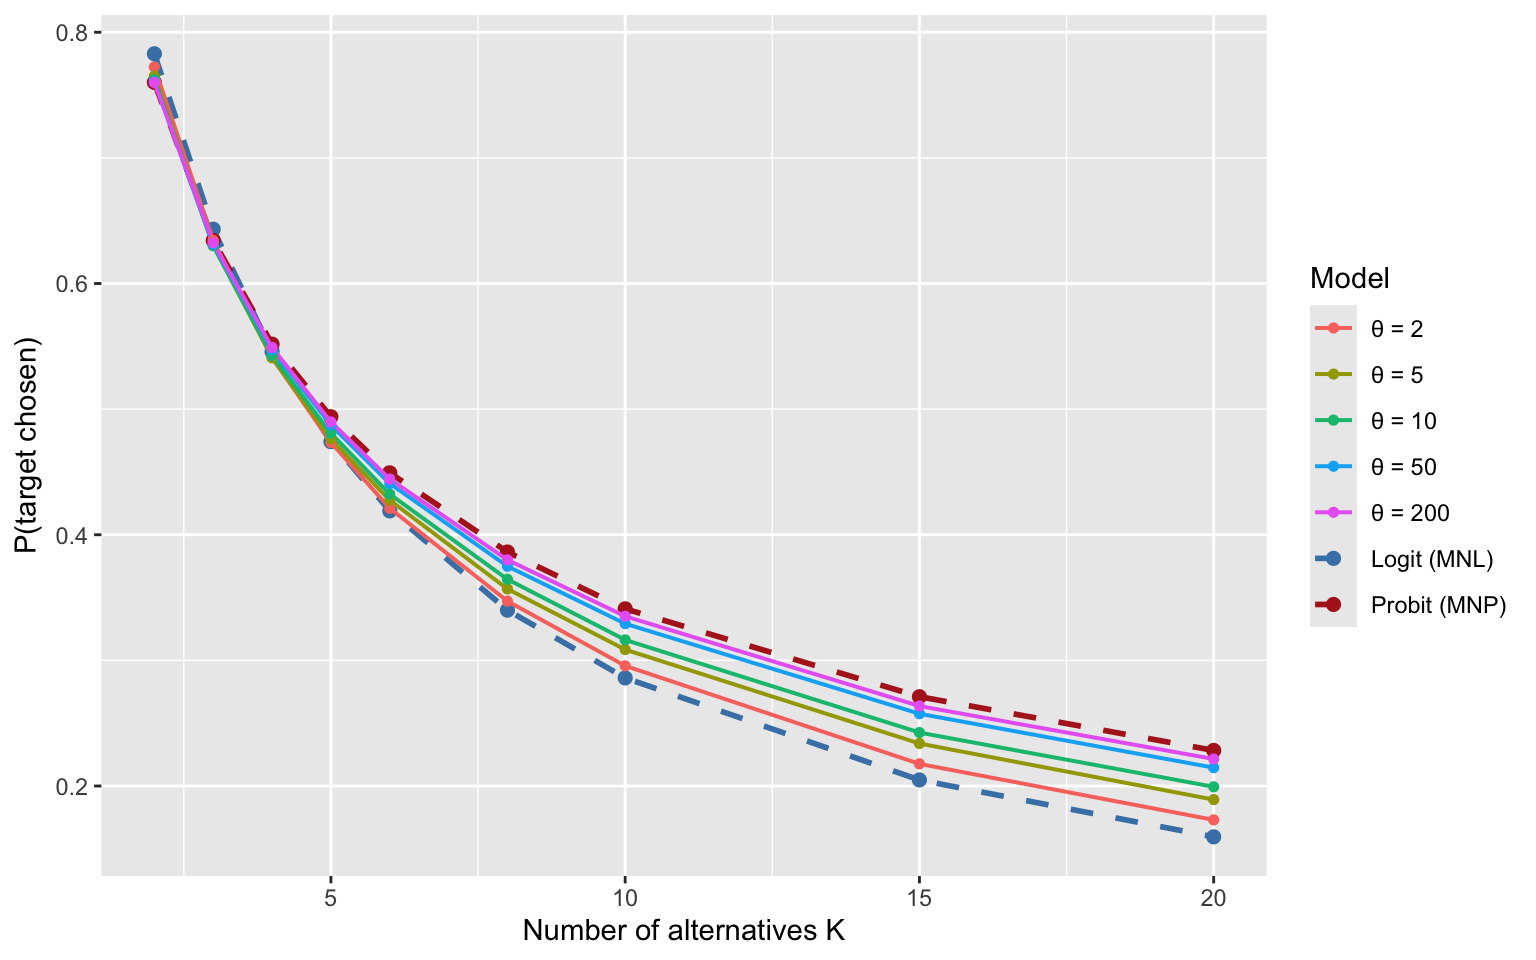

In [ ]:
set.seed(456)
n_sim <- 2e6

Ks <- c(2, 3, 4, 5, 6, 8, 10, 15, 20)
thetas_set <- c(2, 5, 10, 50, 200)

v_target <- 1
v_comp <- 0

df_setsize <- data.frame()

for (K in Ks) {
  v <- c(v_target, rep(v_comp, K - 1))
  
  # References
  p_logit_target <- mnl_probs(v, beta = 1)[1]
  p_probit_target <- mnp_probs(v, beta = 1, n_sim = n_sim)[1]
  
  df_setsize <- rbind(df_setsize, data.frame(
    K = K, theta = NA, prob = p_logit_target, model = "Logit (MNL)"
  ))
  df_setsize <- rbind(df_setsize, data.frame(
    K = K, theta = NA, prob = p_probit_target, model = "Probit (MNP)"
  ))
  
  for (th in thetas_set) {
    p_race <- race_choice_probs(v, theta = th, beta = 1, n_sim = n_sim)
    df_setsize <- rbind(df_setsize, data.frame(
      K = K, theta = th, prob = p_race[1], model = paste0("θ = ", th)
    ))
  }
}

# Separate reference and race data
df_ref_lines <- df_setsize[df_setsize$model %in% c("Logit (MNL)", "Probit (MNP)"), ]
df_race_lines <- df_setsize[!df_setsize$model %in% c("Logit (MNL)", "Probit (MNP)"), ]

df_race_lines$model <- factor(df_race_lines$model, 
                               levels = paste0("θ = ", thetas_set))

ggplot() +
  geom_line(data = df_ref_lines, aes(x = K, y = prob, color = model), 
            linetype = "dashed", linewidth = 1) +
  geom_point(data = df_ref_lines, aes(x = K, y = prob, color = model), size = 2) +
  geom_line(data = df_race_lines, aes(x = K, y = prob, group = model, color = model), 
            linewidth = 0.7) +
  geom_point(data = df_race_lines, aes(x = K, y = prob, color = model), size = 1.3) +
  scale_color_manual(
    values = c(
      "Logit (MNL)" = "steelblue",
      "Probit (MNP)" = "firebrick",
      setNames(scales::hue_pal()(length(thetas_set)), paste0("θ = ", thetas_set))
    )
  ) +
  labs(
    x = "Number of alternatives K",
    y = expression("P(target chosen)"),
    color = "Model"
  ) +
  theme(legend.position = "right")

## Study 4: Independence of Irrelevant Alternatives

The IIA property is a hallmark of the Multinomial Logit model: the ratio of choice probabilities for any two alternatives is invariant to the composition of the choice set. Formally, for alternatives $i$ and $j$:

$$\frac{P(i \mid \mathcal{C})}{P(j \mid \mathcal{C})} = \frac{e^{v_i}}{e^{v_j}} \quad \text{for all choice sets } \mathcal{C} \ni i, j$$

This property does not hold for the Multinomial Probit model, even when errors are independent and identically distributed. The Poisson count race therefore provides a mechanism through which IIA holds exactly at $\theta = 1$ and is progressively violated as $\theta$ increases.

To quantify this, I consider three alternatives with utilities $v = (2, 1, 0)$. I compute the ratio $P(1)/P(2)$ under two conditions:

-   **Full set**: all three alternatives present $\{1, 2, 3\}$
-   **Reduced set**: only alternatives $\{1, 2\}$ present

Under IIA, these ratios should be identical. I track the percentage change in the ratio as $\theta$ varies.

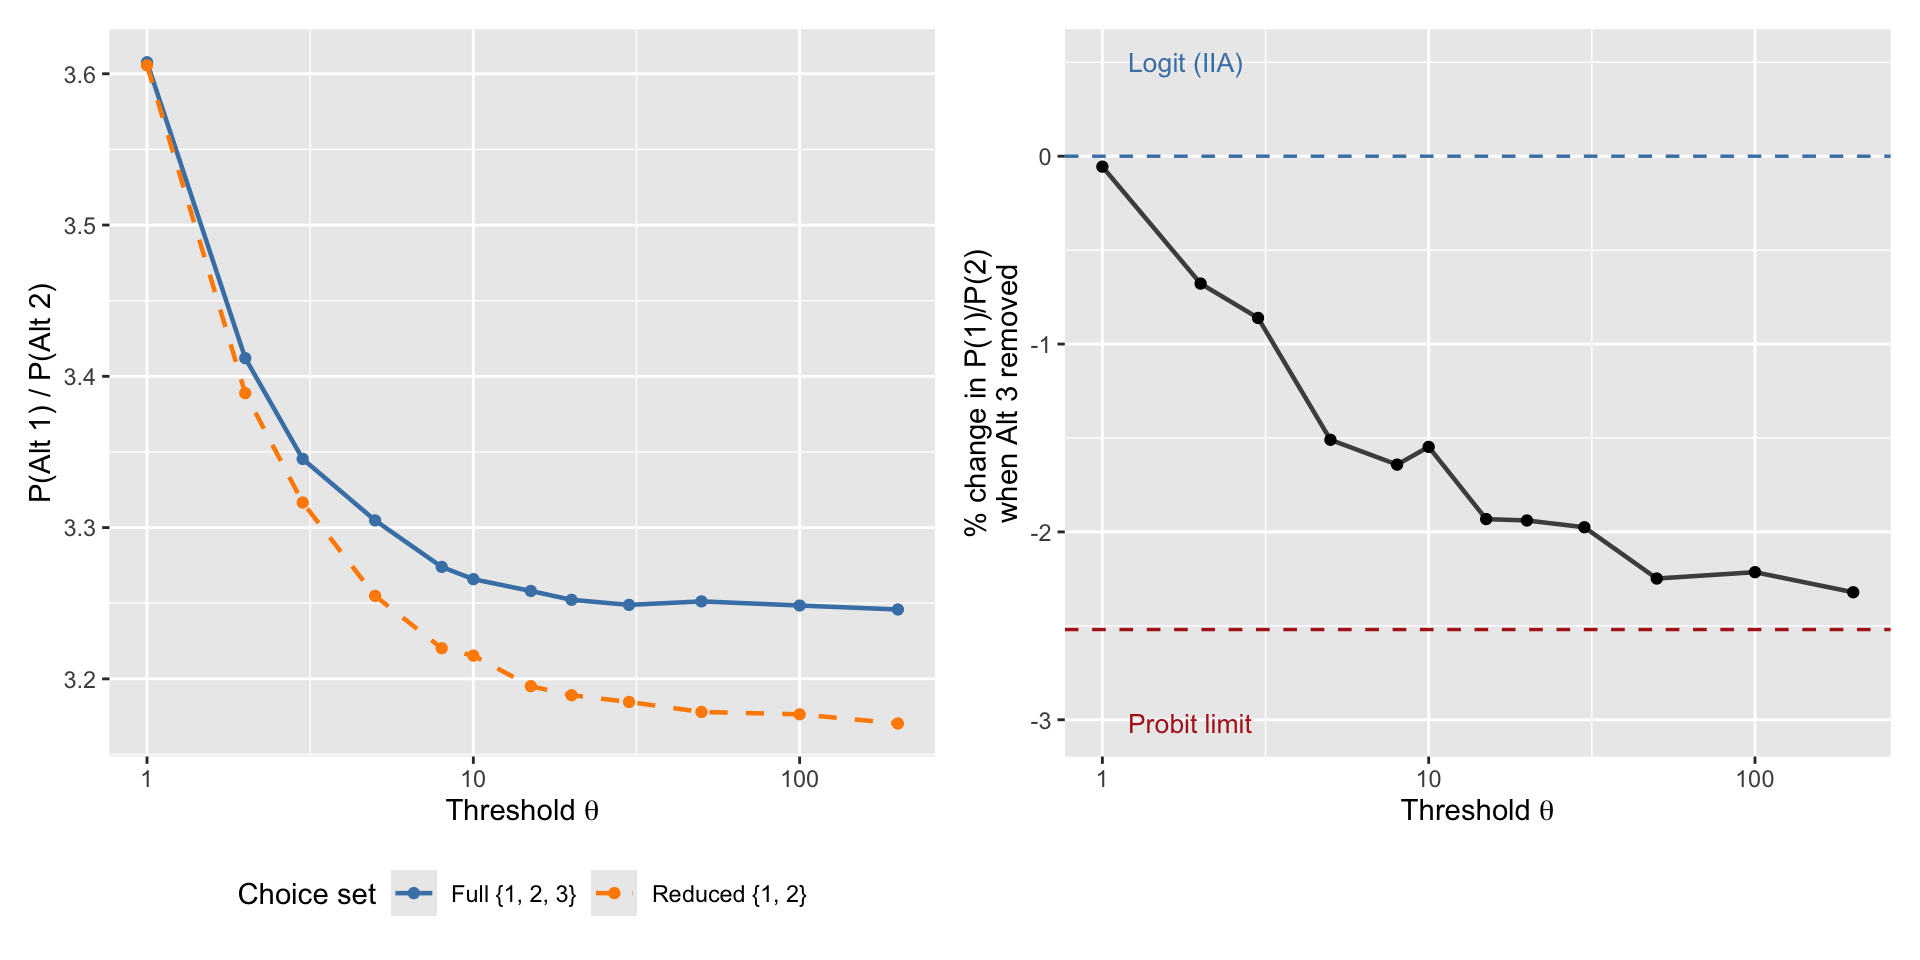

In [ ]:
set.seed(789)
n_sim <- 1e7

v_full <- c(2, 1, 0)
v_reduced <- c(2, 1)

thetas_iia <- c(1, 2, 3, 5, 8, 10, 15, 20, 30, 50, 100, 200)

df_iia <- data.frame()

for (th in thetas_iia) {
  # Full set {1, 2, 3}
  p_full <- race_choice_probs(v_full, theta = th, beta = 1, n_sim = n_sim)
  ratio_full <- p_full[1] / p_full[2]
  
  # Reduced set {1, 2}
  p_reduced <- race_choice_probs(v_reduced, theta = th, beta = 1, n_sim = n_sim)
  ratio_reduced <- p_reduced[1] / p_reduced[2]
  
  df_iia <- rbind(df_iia, data.frame(
    theta = th,
    ratio_full = ratio_full,
    ratio_reduced = ratio_reduced,
    pct_change = 100 * (ratio_reduced - ratio_full) / ratio_full
  ))
}

# Also compute reference values
p_logit_full <- mnl_probs(v_full)[1] / mnl_probs(v_full)[2]
p_logit_reduced <- mnl_probs(v_reduced)[1] / mnl_probs(v_reduced)[2]

p_probit_full <- mnp_probs(v_full, n_sim = 5e6)
r_probit_full <- p_probit_full[1] / p_probit_full[2]
p_probit_reduced <- mnp_probs(v_reduced, n_sim = 5e6)
r_probit_reduced <- p_probit_reduced[1] / p_probit_reduced[2]
probit_pct <- 100 * (r_probit_reduced - r_probit_full) / r_probit_full

# Left panel: ratios
df_ratios <- rbind(
  data.frame(theta = df_iia$theta, ratio = df_iia$ratio_full, 
             set = "Full {1, 2, 3}"),
  data.frame(theta = df_iia$theta, ratio = df_iia$ratio_reduced, 
             set = "Reduced {1, 2}")
)

p1 <- ggplot(df_ratios, aes(x = theta, y = ratio, color = set, linetype = set)) +
  geom_line(linewidth = 0.8) +
  geom_point(size = 1.5) +
  scale_x_log10() +
  scale_linetype_manual(values = c("Full {1, 2, 3}" = "solid", "Reduced {1, 2}" = "dashed")) +
  scale_color_manual(values = c("Full {1, 2, 3}" = "steelblue", "Reduced {1, 2}" = "darkorange")) +
  labs(
    x = expression("Threshold " * theta),
    y = "P(Alt 1) / P(Alt 2)",
    color = "Choice set",
    linetype = "Choice set"
  ) +
  theme(legend.position = "bottom")

# Right panel: IIA violation
p2 <- ggplot(df_iia, aes(x = theta, y = pct_change)) +
  geom_line(linewidth = 0.8, color = "grey30") +
  geom_point(size = 1.5) +
  geom_hline(yintercept = 0, linetype = "dashed", color = "steelblue", linewidth = 0.6) +
  geom_hline(yintercept = probit_pct, linetype = "dashed", color = "firebrick", linewidth = 0.6) +
  annotate("text", x = 1.2, y = 0.5, label = "Logit (IIA)", color = "steelblue", 
           hjust = 0, size = 3.5) +
  annotate("text", x = 1.2, y = probit_pct - 0.5, label = "Probit limit", color = "firebrick", 
           hjust = 0, size = 3.5) +
  scale_x_log10() +
  labs(
    x = expression("Threshold " * theta),
    y = "% change in P(1)/P(2)\nwhen Alt 3 removed"
  )

p1 + p2 + plot_layout(widths = c(1, 1))

## Study 5: Parameter Invariance Across Set Size

A key empirical diagnostic for distinguishing between logit and probit is parameter invariance across changes in set size $K$ \[@robinsonHowPeopleBuild2023\]. If choice data are generated by a logit model, the softmax inverse temperature $\beta_{\text{logit}}$ recovered from fitting a logit specification should remain constant as $K$ increases. Conversely, if the data follow a probit model, the Gaussian noise scale $\beta_{\text{probit}}$ should be invariant to $K$.

I test this directly. For each value of $\theta$ and each set size $K$ (with a target at $v = 1$ vs. $K-1$ equal competitors at $v = 0$), I compute the “true” choice probability $P(\text{target})$ from the race model and then recover the best-fitting logit and probit temperature parameters by inversion.

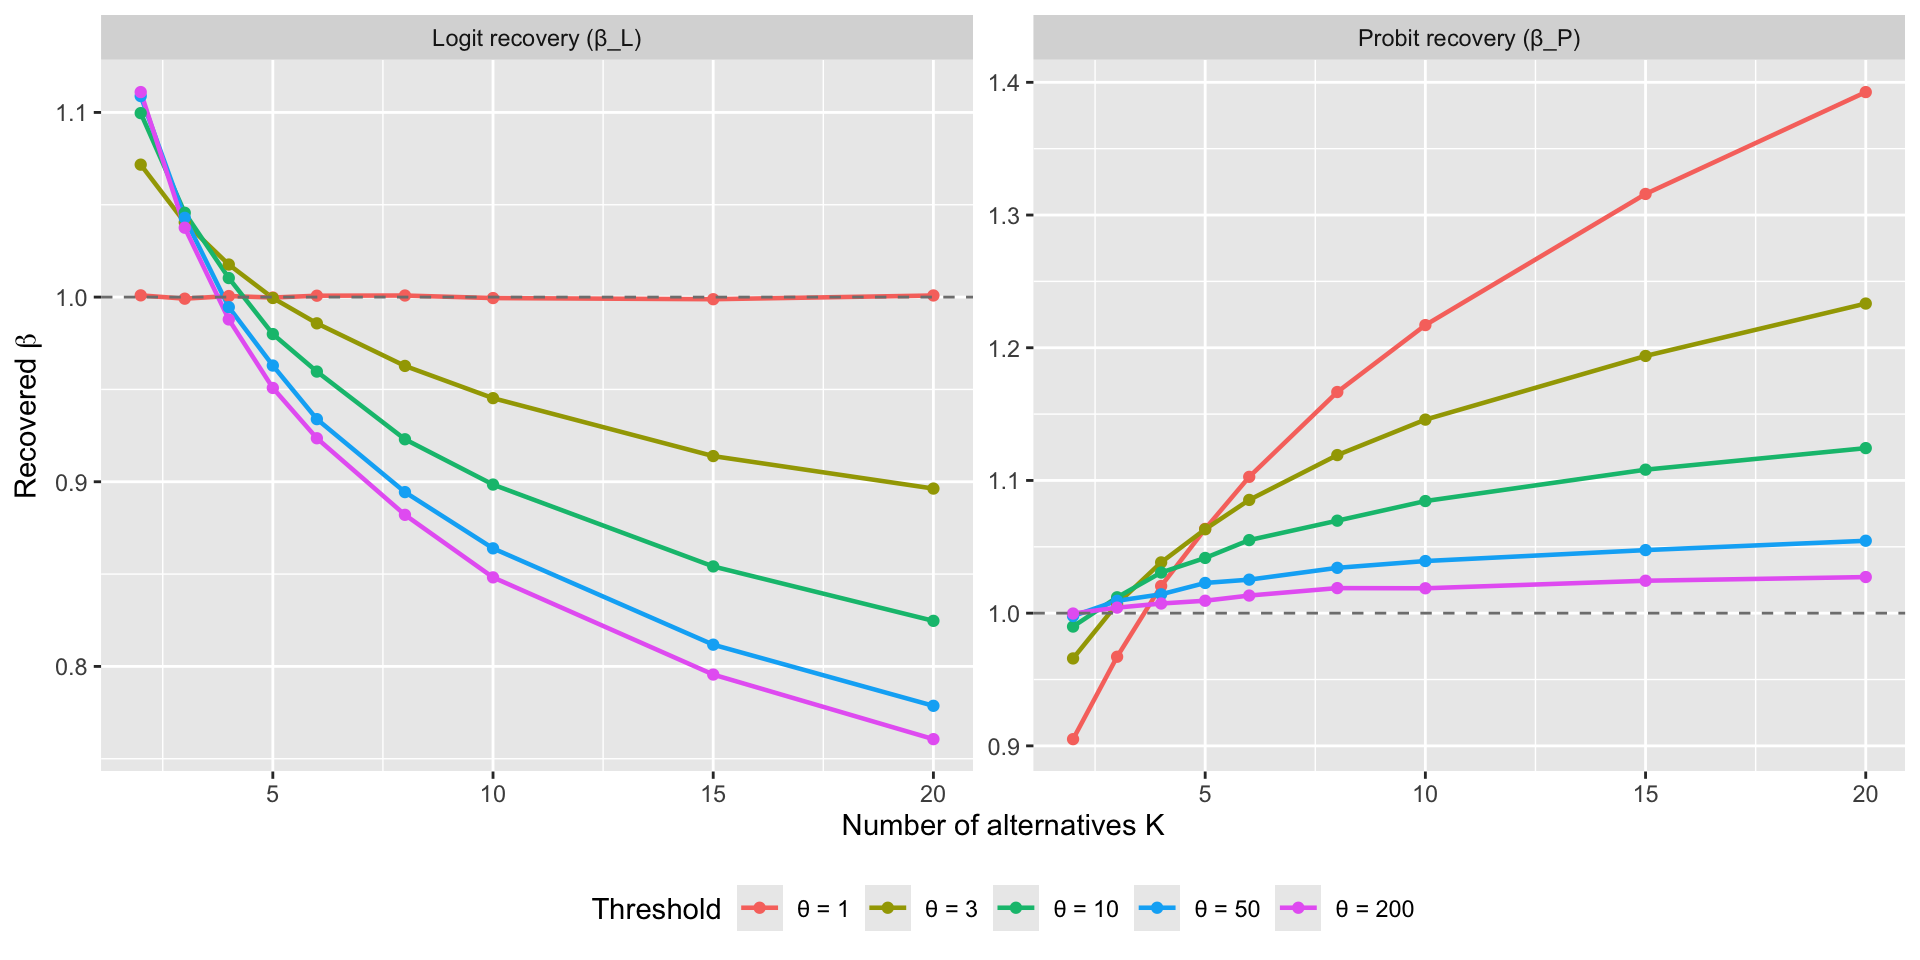

In [ ]:
set.seed(303)
n_sim <- 3e6

Ks_param <- c(2, 3, 4, 5, 6, 8, 10, 15, 20)
thetas_param <- c(1, 3, 10, 50, 200)
v_target <- 1
sigma_G <- pi / sqrt(6)

df_param <- data.frame()

for (th in thetas_param) {
  for (K in Ks_param) {
    v <- c(v_target, rep(0, K - 1))
    p_race <- race_choice_probs(v, theta = th, beta = 1, n_sim = n_sim)[1]
    
    beta_logit <- recover_logit_beta(p_race, v_target, K)
    beta_probit <- recover_probit_beta(p_race, v_target, K)
    
    df_param <- rbind(df_param, data.frame(
      K = K, theta = th, 
      beta_logit = beta_logit, 
      beta_probit = beta_probit,
      model_label = paste0("θ = ", th)
    ))
  }
}

df_param$model_label <- factor(df_param$model_label, 
                                levels = paste0("θ = ", thetas_param))

# Reshape for faceting
df_param_long <- rbind(
  data.frame(K = df_param$K, theta_label = df_param$model_label,
             beta = df_param$beta_logit, recovery = "Logit recovery (β_L)"),
  data.frame(K = df_param$K, theta_label = df_param$model_label,
             beta = df_param$beta_probit, recovery = "Probit recovery (β_P)")
)

ggplot(df_param_long, aes(x = K, y = beta, color = theta_label)) +
  geom_line(linewidth = 0.8) +
  geom_point(size = 1.5) +
  geom_hline(yintercept = 1, linetype = "dashed", color = "grey50", linewidth = 0.5) +
  facet_wrap(~recovery, scales = "free_y") +
  labs(
    x = "Number of alternatives K",
    y = expression("Recovered " * beta),
    color = "Threshold"
  ) +
  theme(legend.position = "bottom")

## Study 6: Distributional Shape — Noise Skewness and Kurtosis

The log-Gamma noise distribution transitions from highly skewed (Gumbel, $\theta = 1$) to symmetric (Gaussian, $\theta \to \infty$). This transition in distributional shape underlies all the choice-level phenomena documented above. To make this explicit, I plot the standardised noise density for several values of $\theta$ alongside the standard normal reference.

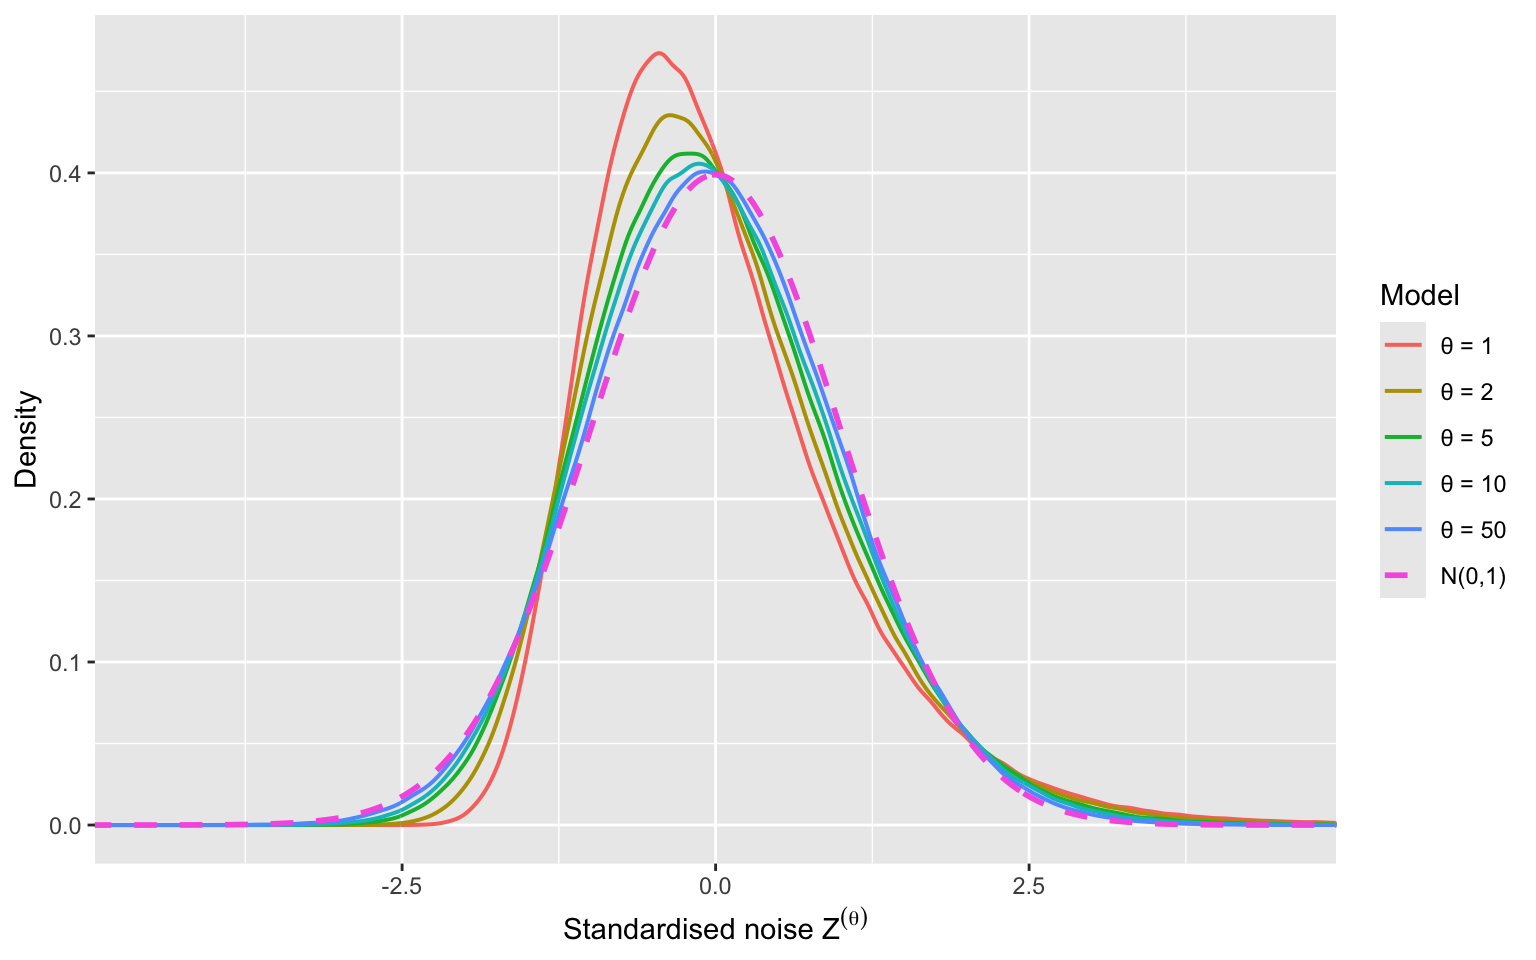

In [ ]:
set.seed(101)
n_draw <- 1e6

thetas_dens <- c(1, 2, 5, 10, 50)

df_dens <- data.frame()

for (th in thetas_dens) {
  G <- rgamma(n_draw, shape = th, rate = 1)
  eps <- -log(G)
  Z <- (eps + digamma(th)) / sqrt(trigamma(th))  # note: +digamma because E[eps] = -digamma
  # Use density estimation
  d <- density(Z, from = -5, to = 5, n = 512)
  df_dens <- rbind(df_dens, data.frame(
    x = d$x, y = d$y, 
    model = paste0("θ = ", th)
  ))
}

# Normal reference
x_norm <- seq(-5, 5, length.out = 512)
df_dens <- rbind(df_dens, data.frame(
  x = x_norm, y = dnorm(x_norm), model = "N(0,1)"
))

df_dens$model <- factor(df_dens$model, 
                         levels = c(paste0("θ = ", thetas_dens), "N(0,1)"))

ggplot(df_dens, aes(x = x, y = y, color = model, linetype = model, linewidth = model)) +
  geom_line() +
  scale_linetype_manual(
    values = c(setNames(rep("solid", length(thetas_dens)), paste0("θ = ", thetas_dens)),
               "N(0,1)" = "dashed")
  ) +
  scale_linewidth_manual(
    values = c(setNames(rep(0.7, length(thetas_dens)), paste0("θ = ", thetas_dens)),
               "N(0,1)" = 1.0)
  ) +
  labs(
    x = expression("Standardised noise " * Z^(theta)),
    y = "Density",
    color = "Model", linetype = "Model", linewidth = "Model"
  ) +
  coord_cartesian(xlim = c(-4.5, 4.5)) +
  theme(legend.position = "right")

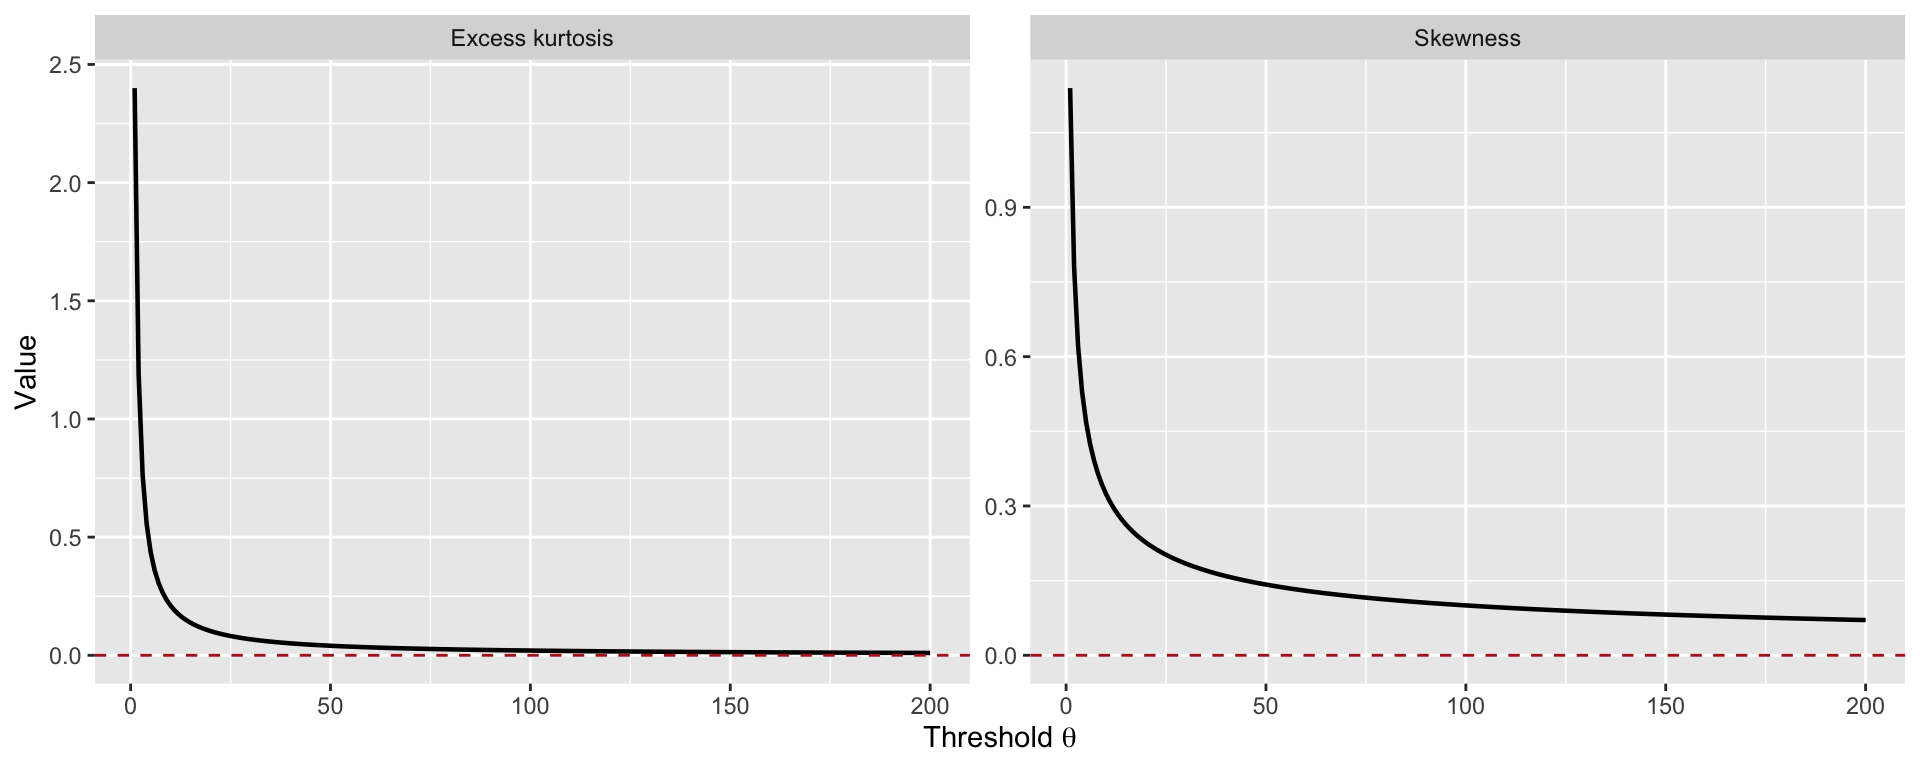

In [ ]:
# Exact skewness and kurtosis of -log(Gamma(theta,1)), standardised
# Skewness = psi_2(theta) / psi_1(theta)^(3/2) where psi_2 is the tetragamma
# Excess kurtosis = psi_3(theta) / psi_1(theta)^2 where psi_3 is the pentagamma
# Note: psigamma(x, deriv=n) gives the n-th derivative of log Gamma
# psi_1 = trigamma, psi_2 = psigamma(,2), psi_3 = psigamma(,3)

thetas_moments <- seq(1, 200, by = 1)

skewness <- -psigamma(thetas_moments, deriv = 2) / trigamma(thetas_moments)^(3/2)
# Note: -log(G) has skewness = -psi_2 / psi_1^{3/2} (the negative sign because of -log)
# Actually: let's be careful. For X = -log(G), E[(X-mu)^3] = -psi_2(theta)
# and Var(X) = psi_1(theta), so skewness = -psi_2(theta) / psi_1(theta)^{3/2}

# Excess kurtosis: E[(X-mu)^4]/Var^2 - 3 = psi_3(theta)/psi_1(theta)^2
ex_kurtosis <- psigamma(thetas_moments, deriv = 3) / trigamma(thetas_moments)^2

df_moments <- rbind(
  data.frame(theta = thetas_moments, value = skewness, moment = "Skewness"),
  data.frame(theta = thetas_moments, value = ex_kurtosis, moment = "Excess kurtosis")
)

ggplot(df_moments, aes(x = theta, y = value)) +
  geom_line(linewidth = 0.8) +
  geom_hline(yintercept = 0, linetype = "dashed", color = "firebrick") +
  facet_wrap(~moment, scales = "free_y") +
  labs(
    x = expression("Threshold " * theta),
    y = "Value"
  )

## Study 7: Robustness Across Utility Structures

The preceding studies used specific utility vectors. To assess robustness, I examine whether the convergence pattern holds across different utility configurations that are common in psychological experiments.

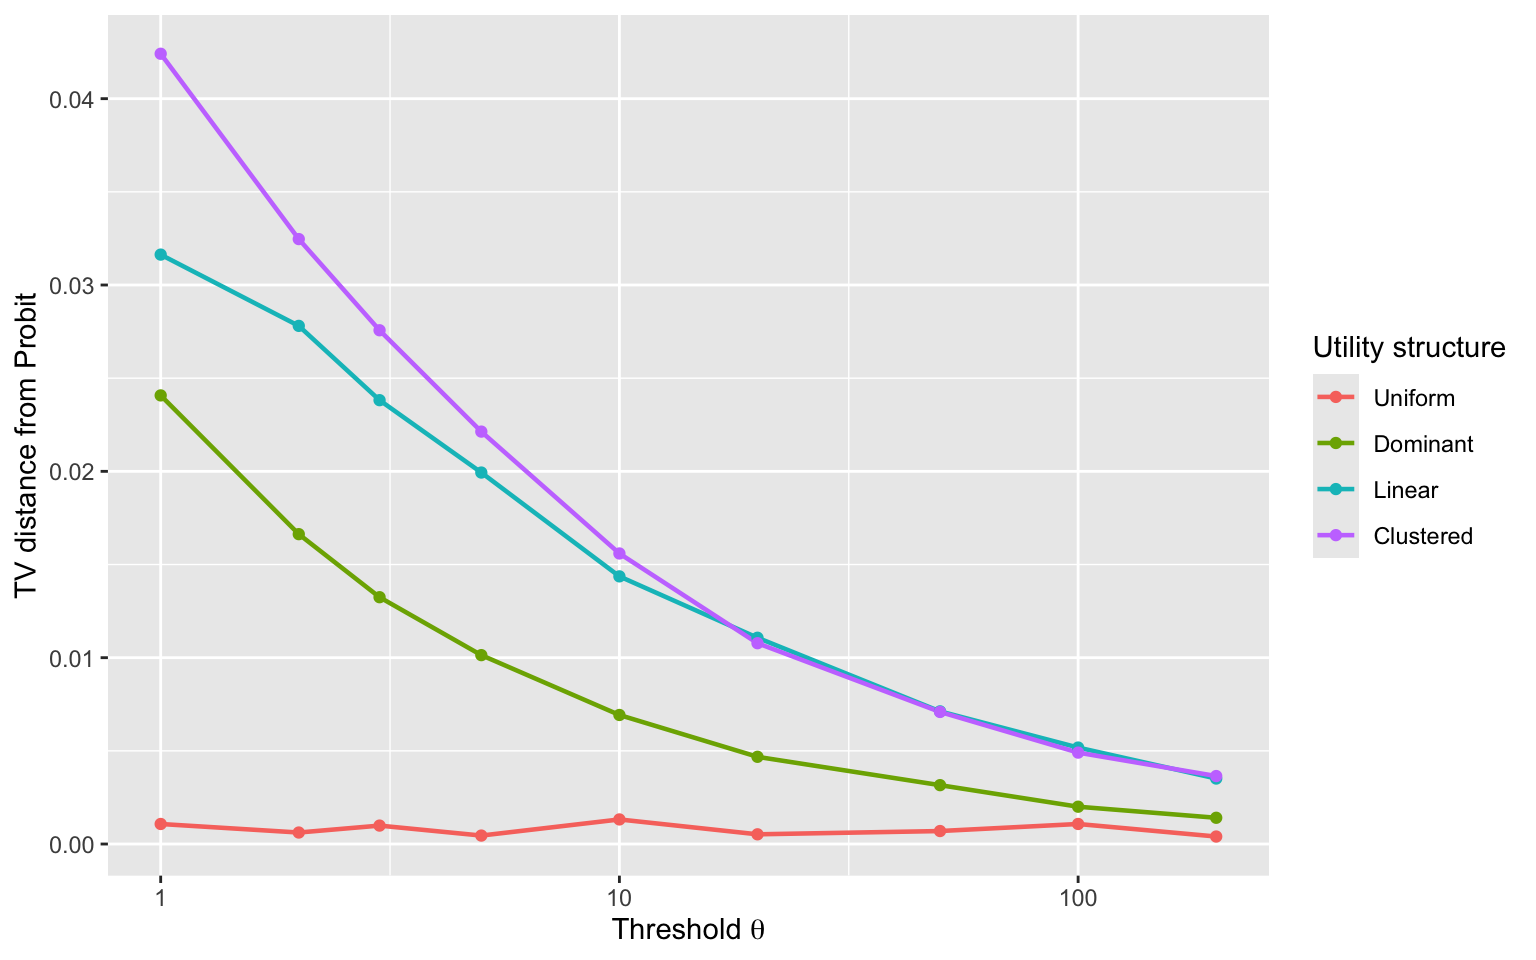

In [ ]:
set.seed(202)
n_sim <- 2e6
K <- 5

configs <- list(
  "Uniform" = rep(0, K),
  "Dominant" = c(3, rep(0, K - 1)),
  "Linear" = seq(2, 0, length.out = K),
  "Clustered" = c(2.0, 1.9, 0.1, 0.0, 0.0)
)

thetas_robust <- c(1, 2, 3, 5, 10, 20, 50, 100, 200)

df_robust <- data.frame()

for (cfg_name in names(configs)) {
  v <- configs[[cfg_name]]
  p_probit <- mnp_probs(v, beta = 1, n_sim = 5e6)
  
  for (th in thetas_robust) {
    p_race <- race_choice_probs(v, theta = th, beta = 1, n_sim = n_sim)
    df_robust <- rbind(df_robust, data.frame(
      theta = th,
      tv_probit = tv_dist(p_race, p_probit),
      config = cfg_name
    ))
  }
}

df_robust$config <- factor(df_robust$config, levels = names(configs))

ggplot(df_robust, aes(x = theta, y = tv_probit, color = config)) +
  geom_line(linewidth = 0.8) +
  geom_point(size = 1.5) +
  scale_x_log10() +
  labs(
    x = expression("Threshold " * theta),
    y = "TV distance from Probit",
    color = "Utility structure"
  ) +
  theme(legend.position = "right")

## Summary

These multinomial simulations confirm and extend the binary-case results:

1.  **Convergence is gradual and universal**: Across different values of $K$ and different utility structures, the Poisson count race converges to the Multinomial Probit reference within $\theta \approx 50$–$100$ in total variation distance.

2.  **Probability redistribution**: As $\theta$ increases, the probit model concentrates more probability on the best alternative and less on inferior alternatives, reflecting the thinner tails of Gaussian noise relative to Gumbel.

3.  **Set-size scaling**: The logit and probit models predict systematically different scaling of target choice probability with the number of competitors. The Poisson count race interpolates between these two patterns, connecting to the empirical findings of \[@robinsonHowPeopleBuild2023\].

4.  **IIA erosion**: The Independence of Irrelevant Alternatives property, which holds exactly at $\theta = 1$, is progressively violated as $\theta$ increases. This provides a process-level account of why IIA holds for logit but not probit: it is a consequence of the Gumbel noise shape, and alternative noise shapes—induced by higher accumulation thresholds—do not preserve it.

5.  **Parameter invariance**: When choice data generated by the Poisson count race are fit under a logit assumption, the recovered inverse temperature drifts with set size $K$ for all $\theta > 1$. Conversely, when fit under a probit assumption, the recovered noise scale remains stable for large $\theta$ but drifts when $\theta$ is small. This cross-over in parameter invariance provides a process-level account of the empirical findings of \[@robinsonHowPeopleBuild2023\]: parameter stability across $K$ is diagnostic of whether the effective noise distribution is closer to Gumbel or Gaussian.

6.  **Noise shape transition**: The underlying mechanism is a smooth transition in the shape of the standardised noise distribution, from the skewed Gumbel ($\theta = 1$) to the symmetric Gaussian ($\theta \to \infty$). The skewness and kurtosis decay at known rates, providing analytic control over the approximation quality.

# Discussion

The present work develops a generative framework in which Multinomial Logit and Multinomial Probit arise as endpoint regimes of a single parametric family of stochastic accumulation models. By introducing a Poisson count race and a temperature identification that separates noise scale from noise shape, this paper clarifies how extreme-value and Gaussian choice behavior emerge as members of the log-Gamma random utility family, indexed by the accumulation threshold $\theta$. As discussed in Section 5, this bridge is distributional rather than dynamical: the temperature identification compares different accumulation systems at matched discriminability, rather than describing the behavior of a single system under threshold manipulation. The goal is not to advocate replacing existing models, but to clarify their relationship: logit and probit represent different positions within a continuum of log-Gamma noise shapes, with the accumulation threshold governing the transition between them.

The multinomial simulations demonstrate that this unification is not merely a theoretical curiosity. Thresholded accumulation induces systematic, graded violations of IIA that converge toward the dependence structure characteristic of multinomial probit. This dependence emerges endogenously from the accumulation and stopping rule, rather than being imposed by construction. The parameter invariance results further connect the framework to recent empirical findings \[@robinsonHowPeopleBuild2023\], providing a process-level account of why Gaussian-based parameters exhibit greater stability across changes in set size.

## Relation to existing models

From a mathematical standpoint, all components of the present framework are classical: exponential races yield Luce’s choice rule, Gamma waiting times arise from accumulated Poisson events, and asymptotic normality follows from the Central Limit Theorem. The contribution lies in assembling these elements into a single generative family and identifying the conditions under which its limiting behavior remains non-degenerate.

The present model should not be conflated with full sequential sampling models such as the Diffusion Decision Model \[@ratcliffTheoryMemoryRetrieval1978\] or Linear Ballistic Accumulator \[@brownBallisticModelChoice2005\]. Those models jointly account for response times and accuracy via continuous accumulation with explicit drift and boundary parameters. The Poisson count race is deliberately minimal: it uses accumulation as a generative device to induce a family of random utility models, without making claims about within-trial dynamics or response time distributions.

Between the logit and probit endpoints lies a continuum of log-Gamma random utility models. These intermediate regimes are not intended as new default specifications, but they underscore that logit and probit are special cases of a broader family. Deviations from logit or probit behavior may sometimes reflect differences in accumulation thresholds rather than fundamentally different noise sources.

## Implications for empirical modeling

The present framework offers a theoretical account of why logit-based and probit-based models may differ in parameter invariance across task structures. Models with larger effective accumulation thresholds naturally exhibit Gaussian-like behavior, which may confer greater stability across changes in the number of alternatives. At the same time, the results caution against interpreting superior empirical performance of one model class as evidence for a particular noise distribution in isolation: differences between logit and probit may reflect differences in decision criteria or commitment thresholds rather than differences in representational noise per se.

## Limitations and extensions

The Poisson count race is intentionally simple. It assumes independent accumulation processes and focuses exclusively on choice probabilities, abstracting away from response times and within-trial dynamics. Extensions that allow correlated accumulators, time-varying rates, or joint modeling of choice and response time are natural directions for future work.

The present analysis treats the accumulation threshold as fixed across trials and alternatives. Allowing threshold variability or adaptive stopping rules could further enrich the family of induced choice models and connect more directly to theories of decision caution and speed–accuracy trade-offs.

The model positions the Poisson count race as a parametric family indexed by $(\theta, \beta)$, but a formal identification analysis is beyond the present scope. In principle, $\theta$ and $\beta$ play distinct roles—shape versus scale of the noise distribution—and the shape of the psychometric function or the pattern of IIA violations could serve to identify $\theta$ from choice data. Whether these parameters are jointly identifiable from aggregate choice frequencies alone, and under what experimental designs, remains an open question for future investigation.

Finally, the framework naturally invites comparison with other random utility specifications. Exploring whether additional classical models arise as limiting regimes under alternative accumulation rules may provide further insight into the structure of discrete choice behavior.

## Concluding remarks

By grounding discrete choice models in a common stochastic accumulation process, the Poisson count race reframes a long-standing modeling distinction. Logit and probit emerge not as competing assumptions about utility noise, but as members of a single parametric family — the log-Gamma random utility models — indexed by the accumulation threshold $\theta$. This unification is algebraic and distributional: it reveals that the two canonical specifications occupy endpoint positions within a continuous family of noise shapes, rather than representing fundamentally distinct generating mechanisms. At the same time, the unification does not imply that a single decision system can transition between regimes by adjusting its threshold alone, since the temperature identification that enables comparison across $\theta$ values entails different effective rate structures. The framework thus clarifies the conceptual relationship between logit and probit and provides a principled basis for comparison, illustrating how process-level reasoning can illuminate the structure of static choice models.